## Prepare dataset

In [1]:
from pathlib import Path

DATASET_NAME = "ITK_Stochastic"
DATA_PATH = "/data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic"
DATA_PATH ="/data/galati/brain_data/ITKTubeTK/fold1"
DATASET_NAME = "COW24_MRCOW24"
DATA_PATH = "/data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1"

OUT_DIR = DATA_PATH + "_PREPROCESSED"
Path(OUT_DIR).mkdir(parents=True, exist_ok=True)

#these functions are to define for each new dataset, unless fixing a rule
#they allow to define a clear association between the data path of a brain image and the corresponding brain/vessel mask
#the brain mask is not mandatory, if not present just return None
import utils
def img_path_to_brain_path(img_path):
    out_path =img_path.replace("/images","/brain")
    return out_path
def img_path_to_vessel_path(img_path):
    out_path =img_path.replace("/images","/labels")
    return out_path
def img_path_to_weight_path(img_path):
    return None

utils.img_path_to_brain_path = img_path_to_brain_path
utils.img_path_to_vessel_path = img_path_to_vessel_path
utils.img_path_to_weight_path = img_path_to_weight_path

#this regex works as a filter in case you have unnecessary .nii files in your dataset folder
PATH_RULE = "^.*MRA.nii.gz$"
#PATH_RULE = ".*/images(Tr|Ts)/.*.nii.gz$"
PATH_RULE = r"^(?:.*/)?images(?:.*/)?topcow_mr_[0-9]{3}\.nii\.gz$"

#if you have some outliers you want to discard, you can specify it in the list below
OUTLIERs = ['IXI371-IOP-0970-MRA.nii.gz']

#if you need to preprocess also images with no vessel masks set the following flag to False
VESSELs_REQUIRED = False

#this parameter is to unify the orientation of our images
#set it True if you notice in the examples shown below that the nose is oriented downward and not upward
utils.do_flip = False

### Extract paths

In [2]:
import os

from utils import search_nii, extract_paths, load_info_from_checkpoint

In [3]:
if not os.path.isfile(f"info_{DATASET_NAME}.pkl"):
    info = {
        "train": extract_paths(path_rule=PATH_RULE),
        "val": None,
        "test": None,
    }
    search_nii(DATA_PATH, info["train"])
else:
    info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

### Display examples

In [4]:
import random

from utils import print_bold, load_and_display_middle_slice

In [5]:
info["train"].paths

['/data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_001.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_002.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_003.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_005.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_006.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_007.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_008.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_010.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_011.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_012.nii.gz',
 '/data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold

[Example 01]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 54
dim             : [  3 504 580 179   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.         0.296875   0.29687497 0.59999835 1.         1.
 1.         1.        ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'TE=3.4;Time=15210.500'
aux_file        : b''
qform_code      : unknown
sform_code      : aligned
quatern_b       : -0.004353664
quatern_c       : -7.118999e-05
quatern_d       : -0.9997891
qof

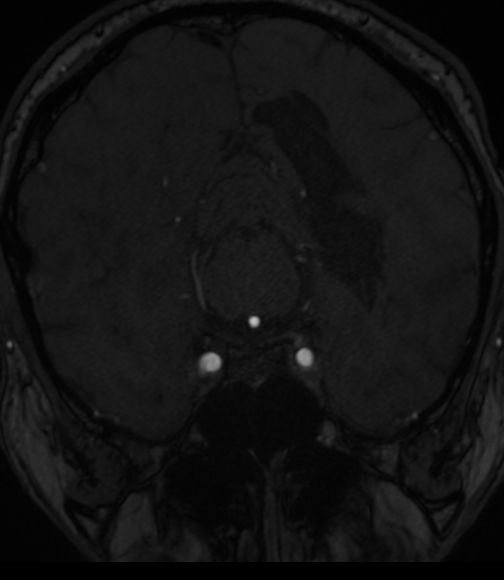

[Example 02]
<class 'nibabel.nifti1.Nifti1Header'> object, endian='<'
sizeof_hdr      : 348
data_type       : b''
db_name         : b''
extents         : 0
session_error   : 0
regular         : b'r'
dim_info        : 54
dim             : [  3 495 577 194   1   1   1   1]
intent_p1       : 0.0
intent_p2       : 0.0
intent_p3       : 0.0
intent_code     : none
datatype        : int16
bitpix          : 16
slice_start     : 0
pixdim          : [1.        0.296875  0.296875  0.6000004 1.        1.        1.
 1.       ]
vox_offset      : 0.0
scl_slope       : nan
scl_inter       : nan
slice_end       : 0
slice_code      : unknown
xyzt_units      : 10
cal_max         : 0.0
cal_min         : 0.0
slice_duration  : 0.0
toffset         : 0.0
glmax           : 0
glmin           : 0
descrip         : b'TE=3.4;Time=163005.985'
aux_file        : b''
qform_code      : unknown
sform_code      : aligned
quatern_b       : 0.007663567
quatern_c       : 9.396591e-05
quatern_d       : 0.9999706
qoffset_x   

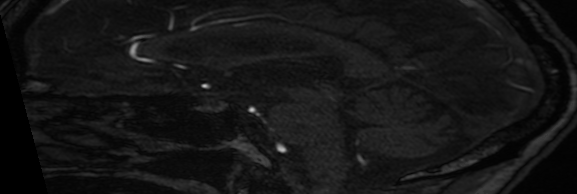

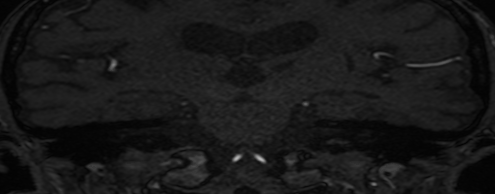

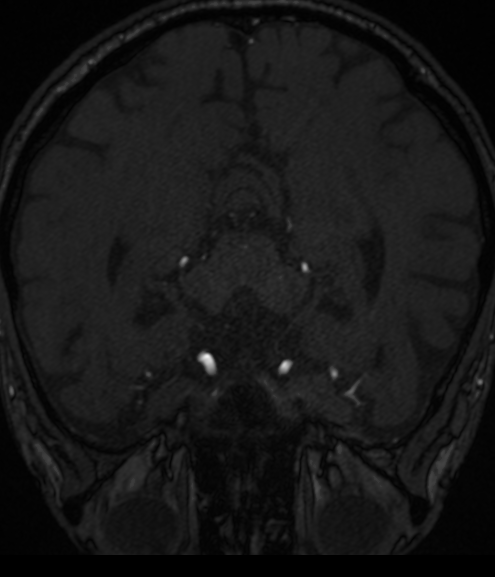

In [6]:
print_bold("[Example 01]")
random.seed(0)
load_and_display_middle_slice(random.choice(info["train"].paths), display_header=True)

print_bold("[Example 02]")
random.seed(1)
load_and_display_middle_slice(random.choice(info["train"].paths), axis=[0,1,2], display_header=True)

### Split train/val/test

In [7]:
from utils import is_medical_volume

In total, there are

In [8]:
IMGs = sum([
    info["train"].paths,
    info["val"].paths if info["val"] is not None else [],
    info["test"].paths if info["test"] is not None else []
], [])

len(IMGs)

250

volumes. First, we discard the outliers:

In [9]:
IMGs = [img_path for img_path in IMGs if os.path.basename(img_path) not in OUTLIERs]

len(IMGs)

250

We have vessel annotations for

In [10]:
HAVE_VESSELs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_vessel_path(img_path))
]

len(HAVE_VESSELs)

250

of them. With a chosen ratio of 70-15-15, we select

In [11]:
COUNT_TEST = 20
COUNT_TEST

20

images to be part of the validation/testing set.

In case brain masks are available, we collect them too.

In [12]:
HAVE_BRAINs = [
    img_path for img_path in IMGs if is_medical_volume(img_path_to_brain_path(img_path))
]

len(HAVE_BRAINs)

0

Finally, we randomly split our dataset. 

In [13]:
random.seed(0)

# all the HAVE_VESSELs that have imagesTs in their path
TEST_IMGs = [img for img in (HAVE_VESSELs if VESSELs_REQUIRED else IMGs) if "imagesTs" in img]
print("test: ", [os.path.basename(img) for img in TEST_IMGs])


random.seed(1)
# COUNT_TEST random HAVE_VESSELs that are not in TEST_IMGs
try:
    VAL_IMGs = random.sample([img for img in HAVE_VESSELs if img not in TEST_IMGs], COUNT_TEST)
except:
    VAL_IMGs = []
print("val: ")
for img in VAL_IMGs:
    print(img)

TRAIN_IMGs = [img for img in (HAVE_VESSELs if VESSELs_REQUIRED else IMGs) if img not in VAL_IMGs and img not in TEST_IMGs]
if VAL_IMGs == []:
    VAL_IMGs = TRAIN_IMGs
print("train: ")
for img in TRAIN_IMGs:
    print(img)

f"Len train: {len(TRAIN_IMGs)}, Len val: {len(VAL_IMGs)}, Len test: {len(TEST_IMGs)}"

test:  ['topcow_mr_001.nii.gz', 'topcow_mr_002.nii.gz', 'topcow_mr_003.nii.gz', 'topcow_mr_004.nii.gz', 'topcow_mr_005.nii.gz', 'topcow_mr_006.nii.gz', 'topcow_mr_007.nii.gz', 'topcow_mr_008.nii.gz', 'topcow_mr_009.nii.gz', 'topcow_mr_010.nii.gz', 'topcow_mr_011.nii.gz', 'topcow_mr_012.nii.gz', 'topcow_mr_013.nii.gz', 'topcow_mr_014.nii.gz', 'topcow_mr_015.nii.gz', 'topcow_mr_016.nii.gz', 'topcow_mr_017.nii.gz', 'topcow_mr_018.nii.gz', 'topcow_mr_019.nii.gz', 'topcow_mr_020.nii.gz', 'topcow_mr_021.nii.gz', 'topcow_mr_022.nii.gz', 'topcow_mr_023.nii.gz', 'topcow_mr_024.nii.gz', 'topcow_mr_025.nii.gz', 'topcow_mr_026.nii.gz', 'topcow_mr_027.nii.gz', 'topcow_mr_028.nii.gz', 'topcow_mr_029.nii.gz', 'topcow_mr_030.nii.gz', 'topcow_mr_031.nii.gz', 'topcow_mr_032.nii.gz', 'topcow_mr_033.nii.gz', 'topcow_mr_034.nii.gz', 'topcow_mr_035.nii.gz', 'topcow_mr_036.nii.gz', 'topcow_mr_037.nii.gz', 'topcow_mr_038.nii.gz', 'topcow_mr_039.nii.gz', 'topcow_mr_040.nii.gz', 'topcow_mr_041.nii.gz', 'topcow_

'Len train: 105, Len val: 20, Len test: 125'

In [14]:
import pickle


with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Extract spacings and shapes

In [15]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [16]:
from utils import extract_info_and_masks, loop_nii, display_info, get_target_spacing

In [17]:
info = {
    "train": extract_info_and_masks(path_rule=PATH_RULE),
    "val": extract_info_and_masks(path_rule=PATH_RULE),
    "test": extract_info_and_masks(path_rule=PATH_RULE),
}

loop_nii(TRAIN_IMGs, info["train"])
loop_nii(VAL_IMGs, info["val"])
loop_nii(TEST_IMGs, info["test"])

In [18]:
try:
    display_info(info["train"], info["val"])
except Exception as e:
     display_info(info["test"], info["test"])

,#volumes,#slices,spacing median,spacing range,shape median,shape range
TRAIN,105,19520,[000.30 000.30 000.60],[000.30 000.30 000.50] - [000.39 000.39 000.80],[480.00 577.00 186.00],[372.00 452.00 138.00] - [560.00 640.00 248.00]
VAL,20,3732,[000.30 000.30 000.60],[000.30 000.30 000.50] - [000.35 000.35 000.60],[479.50 587.50 186.50],[400.00 509.00 152.00] - [520.00 631.00 243.00]


In [19]:
SPACING = get_target_spacing(
    info["train"].spacings + info["val"].spacings,
    info["train"].shapesAfterCropping() + info["val"].shapesAfterCropping()
)

SPACING

array([0.32470703, 0.38269043, 0.59999949])

In [20]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

### Crop, Metadata, Resize, Empty Slices Removal, Standardization

In [21]:
from utils import load_info_from_checkpoint

info = load_info_from_checkpoint(f"info_{DATASET_NAME}.pkl")

In [22]:
import os
import numpy as np

from utils import print_bold, preprocessing_loop_256

In [23]:
#SPACING = np.array([0.46875   , 0.46875   , 0.79999992])

In [24]:
print_bold("Validation")
preprocessing_loop_256(
    info["val"],
    os.path.join(OUT_DIR,"numpy", "val"),
    target_spacing=SPACING,
    save_unique=False,
    new_shape=[256, 256]
)

Validation


  0%|          | 0/20 [00:00<?, ?it/s]



Processing /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_023.nii.gz
(495, 577, 194)
Vessel mask path:  /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/labelsTr/topcow_mr_023.nii.gz
Target spacing: [0.32470703 0.38269043 0.59999949]
Current spacing: [0.296875  0.296875  0.6000004]

=== Resampled ===
Image - Spacing: (0.32470077, 0.38269043, 0.60001326), Shape: (495, 577, 194)
Mask  - Shape: (495, 577, 194)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.6278394, 0.86254835, 0.60001326), Shape: (256, 256, 194)
Mask  - Shape: (256, 256, 194)
Got - Image: (256, 256, 194), Mask: (256, 256, 194)


  5%|▌         | 1/20 [00:09<03:03,  9.66s/it]

Slices processed: 256


Processing /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_087.nii.gz
(500, 577, 181)
Vessel mask path:  /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/labelsTr/topcow_mr_087.nii.gz
Target spacing: [0.32470703 0.38269043 0.59999949]
Current spacing: [0.296875  0.296875  0.6000003]

=== Resampled ===
Image - Spacing: (0.3247474, 0.3826537, 0.60000587), Shape: (500, 577, 181)
Mask  - Shape: (500, 577, 181)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.63427234, 0.8624656, 0.60000587), Shape: (256, 256, 181)
Mask  - Shape: (256, 256, 181)
Got - Image: (256, 256, 181), Mask: (256, 256, 181)


...

Slices processed: 4608


Processing /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_058.nii.gz
(485, 571, 184)
Vessel mask path:  /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/labelsTr/topcow_mr_058.nii.gz
Target spacing: [0.32470703 0.38269043 0.59999949]
Current spacing: [0.296875   0.296875   0.59999883]

=== Resampled ===
Image - Spacing: (0.32471672, 0.3826707, 0.6000295), Shape: (485, 571, 184)
Mask  - Shape: (485, 571, 184)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.615186, 0.853535, 0.6000295), Shape: (256, 256, 184)
Mask  - Shape: (256, 256, 184)
Got - Image: (256, 256, 184), Mask: (256, 256, 184)


 95%|█████████▌| 19/20 [03:09<00:10, 10.09s/it]

Slices processed: 4864


Processing /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_073.nii.gz
(495, 607, 194)
Vessel mask path:  /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/labelsTr/topcow_mr_073.nii.gz
Target spacing: [0.32470703 0.38269043 0.59999949]
Current spacing: [0.296875   0.296875   0.60000217]

=== Resampled ===
Image - Spacing: (0.32462582, 0.38194093, 0.60212594), Shape: (495, 607, 194)
Mask  - Shape: (495, 607, 194)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.6276944, 0.9056178, 0.60212594), Shape: (256, 256, 194)
Mask  - Shape: (256, 256, 194)
Got - Image: (256, 256, 194), Mask: (256, 256, 194)


100%|██████████| 20/20 [03:18<00:00,  9.95s/it]

Slices processed: 5120


In [25]:
print_bold("Training")
preprocessing_loop_256(
    info["train"],
    os.path.join(OUT_DIR,"numpy", "train"),
    target_spacing=SPACING,
    save_unique=False,
    new_shape = [256,256]
    
)

Training


  0%|          | 0/105 [00:00<?, ?it/s]



Processing /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_001.nii.gz
(508, 585, 189)
Vessel mask path:  /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/labelsTr/topcow_mr_001.nii.gz
Target spacing: [0.32470703 0.38269043 0.59999949]
Current spacing: [0.296875  0.296875  0.5999942]

=== Resampled ===
Image - Spacing: (0.32444623, 0.3825051, 0.60105747), Shape: (508, 585, 189)
Mask  - Shape: (508, 585, 189)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.643823, 0.87408394, 0.60105747), Shape: (256, 256, 189)
Mask  - Shape: (256, 256, 189)
Got - Image: (256, 256, 189), Mask: (256, 256, 189)


  1%|          | 1/105 [00:09<16:35,  9.57s/it]

Slices processed: 256


Processing /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_002.nii.gz
(480, 536, 248)
Vessel mask path:  /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/labelsTr/topcow_mr_002.nii.gz
Target spacing: [0.32470703 0.38269043 0.59999949]
Current spacing: [0.29687497 0.296875   0.6000016 ]

=== Resampled ===
Image - Spacing: (0.32472092, 0.3824318, 0.6006421), Shape: (480, 536, 248)
Mask  - Shape: (480, 536, 248)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.60885173, 0.8007166, 0.6006421), Shape: (256, 256, 248)
Mask  - Shape: (256, 256, 248)
Got - Image: (256, 256, 248), Mask: (256, 256, 248)


...

Slices processed: 26368


Processing /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_155.nii.gz
(525, 561, 175)
Vessel mask path:  /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/labelsTr/topcow_mr_155.nii.gz
Target spacing: [0.32470703 0.38269043 0.59999949]
Current spacing: [0.296875   0.296875   0.59999794]

=== Resampled ===
Image - Spacing: (0.32478097, 0.38246846, 0.600414), Shape: (525, 561, 175)
Mask  - Shape: (525, 561, 175)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.6660547, 0.83814377, 0.600414), Shape: (256, 256, 175)
Mask  - Shape: (256, 256, 175)
Got - Image: (256, 256, 175), Mask: (256, 256, 175)


 99%|█████████▉| 104/105 [17:17<00:11, 11.03s/it]

Slices processed: 26624


Processing /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTr/topcow_mr_147.nii.gz
(484, 551, 200)
Vessel mask path:  /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/labelsTr/topcow_mr_147.nii.gz
Target spacing: [0.32470703 0.38269043 0.59999949]
Current spacing: [0.296875  0.296875  0.6000037]

=== Resampled ===
Image - Spacing: (0.32473823, 0.3826584, 0.600014), Shape: (484, 551, 200)
Mask  - Shape: (484, 551, 200)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.6139582, 0.8236124, 0.600014), Shape: (256, 256, 200)
Mask  - Shape: (256, 256, 200)
Got - Image: (256, 256, 200), Mask: (256, 256, 200)


100%|██████████| 105/105 [17:29<00:00, 10.00s/it]

Slices processed: 26880


In [26]:
print_bold("Testing")
preprocessing_loop_256(
    info["test"],
    os.path.join(OUT_DIR,"numpy", "test"),
    target_spacing=SPACING,
    save_unique=False,
    new_shape = [256,256]
)

Testing


  0%|          | 0/125 [00:00<?, ?it/s]



Processing /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTs/topcow_mr_001.nii.gz
(508, 585, 189)
Vessel mask path:  /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/labelsTs/topcow_mr_001.nii.gz
Target spacing: [0.32470703 0.38269043 0.59999949]
Current spacing: [0.296875  0.296875  0.5999942]

=== Resampled ===
Image - Spacing: (0.32444623, 0.3825051, 0.60105747), Shape: (508, 585, 189)
Mask  - Shape: (508, 585, 189)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.643823, 0.87408394, 0.60105747), Shape: (256, 256, 189)
Mask  - Shape: (256, 256, 189)
Got - Image: (256, 256, 189), Mask: (256, 256, 189)


  1%|          | 1/125 [00:10<21:18, 10.31s/it]

Slices processed: 256


Processing /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTs/topcow_mr_002.nii.gz
(480, 536, 248)
Vessel mask path:  /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/labelsTs/topcow_mr_002.nii.gz
Target spacing: [0.32470703 0.38269043 0.59999949]
Current spacing: [0.29687497 0.296875   0.6000016 ]

=== Resampled ===
Image - Spacing: (0.32472092, 0.3824318, 0.6006421), Shape: (480, 536, 248)
Mask  - Shape: (480, 536, 248)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.60885173, 0.8007166, 0.6006421), Shape: (256, 256, 248)
Mask  - Shape: (256, 256, 248)
Got - Image: (256, 256, 248), Mask: (256, 256, 248)


...

Slices processed: 31488


Processing /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTs/topcow_mr_164.nii.gz
(449, 602, 189)
Vessel mask path:  /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/labelsTs/topcow_mr_164.nii.gz
Target spacing: [0.32470703 0.38269043 0.59999949]
Current spacing: [0.3125     0.31250003 0.5999986 ]

=== Resampled ===
Image - Spacing: (0.32453287, 0.38269013, 0.60034746), Shape: (449, 602, 189)
Mask  - Shape: (449, 602, 189)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.5692002, 0.89991975, 0.60034746), Shape: (256, 256, 189)
Mask  - Shape: (256, 256, 189)
Got - Image: (256, 256, 189), Mask: (256, 256, 189)


 99%|█████████▉| 124/125 [20:29<00:09,  9.95s/it]

Slices processed: 31744


Processing /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/imagesTs/topcow_mr_165.nii.gz
(480, 582, 216)
Vessel mask path:  /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1/labelsTs/topcow_mr_165.nii.gz
Target spacing: [0.32470703 0.38269043 0.59999949]
Current spacing: [0.296875  0.296875  0.5999985]

=== Resampled ===
Image - Spacing: (0.32492912, 0.3825019, 0.5999995), Shape: (480, 582, 216)
Mask  - Shape: (480, 582, 216)
Shape verification: OK

=== Downsized ===
Image - Spacing: (0.6092421, 0.86959416, 0.5999995), Shape: (256, 256, 216)
Mask  - Shape: (256, 256, 216)
Got - Image: (256, 256, 216), Mask: (256, 256, 216)


100%|██████████| 125/125 [20:40<00:00,  9.92s/it]

Slices processed: 32000


In [27]:
import pickle

with open(f"info_{DATASET_NAME}.pkl", "wb") as file:
    pickle.dump({
        k: info[k].__dict__ if info[k] is not None else None for k in info
    }, file)

In [28]:
#REMEMBER TO START FROM 0 !
print("DONE: OUT_DIR = ", OUT_DIR)

DONE: OUT_DIR =  /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1_PREPROCESSED


In [30]:
import os
from pathlib import Path
import shutil 

def rename_dataset(DATASET_PATH_RENAMED, OUTPUT_PATH_RENAMED, counter=0):
    print(f"Starting from counter: {counter+1}")
    # DELETE OUTPUT FOLDER IF EXISTS
    if os.path.exists(OUTPUT_PATH_RENAMED):
        shutil.rmtree(OUTPUT_PATH_RENAMED)
    
    Path(OUTPUT_PATH_RENAMED).mkdir(parents=True, exist_ok=True)

    print("Number of subjects: ", len(os.listdir(DATASET_PATH_RENAMED))/3)
    os.listdir(DATASET_PATH_RENAMED)

    dict_id = {}

    for img in os.listdir(DATASET_PATH_RENAMED):
        patient_id = img.split("_")[2]
        if patient_id not in dict_id:
            counter += 1
            dict_id[patient_id] = str(counter).zfill(3)
        # copy to output folder and rename\
        print("Renaming ", img, " to ", dict_id[patient_id] + "_" + img)
        shutil.copy(os.path.join(DATASET_PATH_RENAMED, img), os.path.join(OUTPUT_PATH_RENAMED, dict_id[patient_id] + "_" + img))
        #os.rename(os.path.join(DATASET_PATH_RENAMED, img), os.path.join(OUTPUT_PATH_RENAMED, dict_id[patient_id] + "_" + img))
    return counter
tr_counter = rename_dataset(os.path.join(OUT_DIR, "numpy", "train"), os.path.join(OUT_DIR, "numpy_renamed", "train"), -1)
vl_counter = rename_dataset(os.path.join(OUT_DIR, "numpy", "val"), os.path.join(OUT_DIR, "numpy_renamed", "val"), tr_counter)
rename_dataset(os.path.join(OUT_DIR, "numpy", "test"), os.path.join(OUT_DIR, "numpy_renamed", "test"), vl_counter)

Starting from counter: 0
Number of subjects:  105.0
Renaming  topcow_mr_001_ToF.nii.gz  to  000_topcow_mr_001_ToF.nii.gz
Renaming  topcow_mr_001_brain_mask.nii.gz  to  000_topcow_mr_001_brain_mask.nii.gz
Renaming  topcow_mr_001_vessel.nii.gz  to  000_topcow_mr_001_vessel.nii.gz
Renaming  topcow_mr_002_ToF.nii.gz  to  001_topcow_mr_002_ToF.nii.gz
Renaming  topcow_mr_002_brain_mask.nii.gz  to  001_topcow_mr_002_brain_mask.nii.gz
Renaming  topcow_mr_002_vessel.nii.gz  to  001_topcow_mr_002_vessel.nii.gz
Renaming  topcow_mr_003_ToF.nii.gz  to  002_topcow_mr_003_ToF.nii.gz
Renaming  topcow_mr_003_brain_mask.nii.gz  to  002_topcow_mr_003_brain_mask.nii.gz
Renaming  topcow_mr_003_vessel.nii.gz  to  002_topcow_mr_003_vessel.nii.gz
Renaming  topcow_mr_006_ToF.nii.gz  to  003_topcow_mr_006_ToF.nii.gz
Renaming  topcow_mr_006_brain_mask.nii.gz  to  003_topcow_mr_006_brain_mask.nii.gz
Renaming  topcow_mr_006_vessel.nii.gz  to  003_topcow_mr_006_vessel.nii.gz
Renaming  topcow_mr_007_ToF.nii.gz  to  

249

In [ ]:
# import os
# import re
# from pathlib import Path

# def rename_files(directory):
#     """
#     Rename files by incrementing the prefix number (022, 023, 024, etc.)
#     """
#     # Get all files in the directory
#     files = sorted([f for f in Path(directory).iterdir() if f.is_file()])
    
#     # Group files by their sequence number to handle pairs/triplets together
#     file_groups = {}
#     for file in files:
#         # Extract the sequence number (e.g., '000' from '022_topcow_mr_whole_000_ToF.nii.gz')
#         match = re.search(r'_(\d{3})_', file.name)
#         if match:
#             seq_num = match.group(1)
#             if seq_num not in file_groups:
#                 file_groups[seq_num] = []
#             file_groups[seq_num].append(file)
    
#     # Process each group
#     sorted_seq_nums = sorted(file_groups.keys())
#     for i, seq_num in enumerate(sorted_seq_nums):
#         new_prefix = str(22 + i).zfill(3)  # Start at 022, then 023, 024, etc.
        
#         # Process all files in this group (ToF, brain_mask, vessel)
#         for file in file_groups[seq_num]:
#             # Replace old prefix (022) with new prefix while keeping the rest of filename
#             new_name = re.sub(r'^022_', f'{new_prefix}_', file.name)
#             new_path = file.parent / new_name
            
#             # Print the renaming operation
#             print(f"Renaming: {file.name} -> {new_name}")
            
#             # Uncomment the following line to actually perform the rename
#             file.rename(new_path)

# rename_files('/data/falcetta/NNUNET25/nnUNet_raw/CTCOW23_Stochastic_PREPROCESSED/numpy_renamed/test')

In [31]:
print("All done!")

print(f"PREPROCESSING DONE! Dataset saved in {OUT_DIR}/numpy_renamed")

All done!
PREPROCESSING DONE! Dataset saved in /data/falcetta/NNUNET25/nnUNet_raw/Dataset304_MRCOW24/fold1_PREPROCESSED/numpy_renamed
